In [1]:
import os
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('../data/raw/train.csv')
df.head(2)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,9117000170,20150505T000000,268643,4,2.25,1810,9240,2.0,0,0,...,7,1810,0,1961,0,98055,47.4362,-122.187,1660,9240
1,6700390210,20140708T000000,245000,3,2.50,1600,2788,2.0,0,0,...,7,1600,0,1992,0,98031,47.4034,-122.187,1720,3605


In [3]:
#converting to numeric..cleaning data
df = df.apply(pd.to_numeric, errors='coerce')
df = df.fillna(0)

In [4]:
#creating df1...
image_dir = '../data/raw/images'

available_images = set([
    int(f.split(".")[0]) for f in os.listdir(image_dir)
])

df1 = df[df["id"].isin(available_images)]

df1 = df1.drop_duplicates(subset="id")

In [5]:
#feature engineering
#["total_sqft"] = df1["sqft_living"] + df1["sqft_basement"]
#power features
#df1["avg_room_size"] = df1["sqft_living"] / (df1["bedrooms"] + 1)

#drop weak features
#df1 = df1.drop([
#  "yr_renovated"
#], axis=1) 


In [6]:
#creating manually datasets

images = []
tabular = []
prices = []

for i, row in df1.iterrows():
    img_id = int(row["id"])
    
    # Load image
    img_path = f"../data/raw/images/{img_id}.png"
    img = cv2.imread(img_path)
    
    if img is None:
        continue
    
    # Resize 
    img = cv2.resize(img, (224, 224))
    images.append(img)

    # Tabular features 
    features = row.drop(["id", "price"]).values
    tabular.append(features)

    # Target
    prices.append(row["price"])


In [7]:
#converting to numpy arrays
images = np.array(images, dtype="float32") / 255.0
tabular = np.array(tabular, dtype="float32")
prices = np.array(prices, dtype="float32")

#scale prices
#prices = prices / 100000   # scale down

In [8]:
# Scaling 
from sklearn.preprocessing import StandardScaler

prices = prices.reshape(-1, 1)

price_scaler = StandardScaler()
prices = price_scaler.fit_transform(prices)


In [9]:
#normalise the tabular data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
tabular = scaler.fit_transform(tabular)

In [10]:
#train test split
from sklearn.model_selection import train_test_split

X_img_train, X_img_test, X_tab_train, X_tab_test, y_train, y_test = train_test_split(
    images, tabular, prices, test_size=0.2, random_state=42
)

In [11]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dropout, Input, Dense, Conv2D, Flatten, MaxPooling2D, Concatenate

In [12]:
#Image Branch (CNN)
image_input = Input(shape=(224, 224, 3))

x = Conv2D(32, (3,3), activation='relu')(image_input)
x = MaxPooling2D()(x)

x = Conv2D(64, (3,3), activation='relu')(x)
x = MaxPooling2D()(x)

x = Flatten()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x) #add dropout

In [13]:
#Tabular Branch
tabular_input = Input(shape=(tabular.shape[1],))

y = Dense(64, activation='relu')(tabular_input)
y = Dense(32, activation='relu')(y)
y = Dropout(0.3)(y) #add dropout

In [14]:
#Combined both
combined = Concatenate()([x, y])

z = Dense(128, activation='relu')(combined)
z = Dense(64, activation='relu')(z)
z = Dense(32, activation='relu')(z)
z = Dense(1)(z)

In [15]:
model = Model(inputs=[image_input, tabular_input], outputs=z)

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 222, 222,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 111, 111,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 54, 54,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 19)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 186624)    │          0 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      1,280 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │ 11,944,000 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96)        │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     12,416 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      8,256 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 32)        │      2,080 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1)         │         33 │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,989,537 (45.74 MB)

 Trainable params: 11,989,537 (45.74 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
#train for 10-15 epochs 
#model train 2.0
model.fit(
    [X_img_train, X_tab_train],
    y_train,
    epochs=10,
    batch_size=16
)

Epoch 1/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 222ms/step - loss: 1.6349 - mae: 0.8824
Epoch 2/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 213ms/step - loss: 0.6693 - mae: 0.5757
Epoch 3/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 210ms/step - loss: 0.4856 - mae: 0.4758
Epoch 4/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 206ms/step - loss: 0.3983 - mae: 0.4361
Epoch 5/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 215ms/step - loss: 0.3635 - mae: 0.3958
Epoch 6/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 212ms/step - loss: 0.2991 - mae: 0.3840
Epoch 7/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 214ms/step - loss: 0.2849 - mae: 0.3806
Epoch 8/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 214ms/step - loss: 0.2703 - mae: 0.3368
Epoch 9/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 214ms/step - loss: 0.2320 - mae: 0.3437
Epoch 10/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 216ms/step - loss: 0.2300 - mae: 0.3337


In [17]:
# 🔹 Predict
preds = model.predict([X_img_test, X_tab_test])

# 🔹 Convert back to original price scale
preds_actual = price_scaler.inverse_transform(preds)
y_test_actual = price_scaler.inverse_transform(y_test)

# 🔹 Evaluate
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test_actual, preds_actual)
print("MAE ₹:", mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
MAE ₹: 109929.1953125


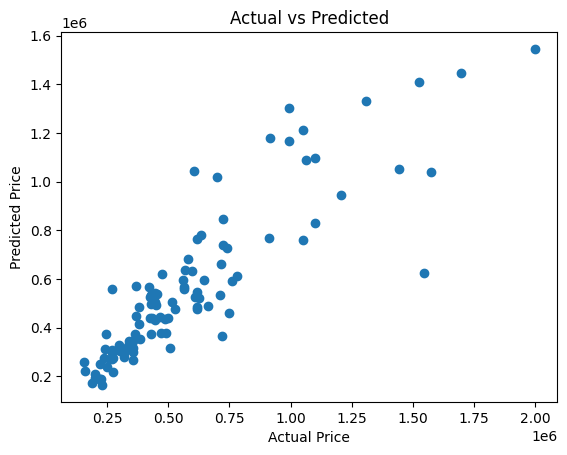

In [18]:
#viswualize model
plt.scatter(y_test_actual, preds_actual)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

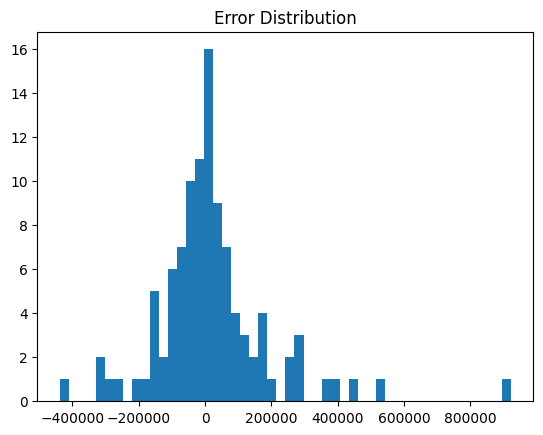

In [19]:
#error distribution
errors = y_test_actual - preds_actual

plt.hist(errors, bins=50)
plt.title("Error Distribution")
plt.show()